# C++ 运算符重载

# 1. 运算符重载简介

① 运算符重载：对已有的运算符重新进行定义，赋予其另一种功能，以适应不同的数据类型。

② 对于内置的数据类型的表达式的运算符是不可能改变的。

# 2. 加号运算符重载

① 加号运算符作用：实现两个自定义数据类型相加的运算。

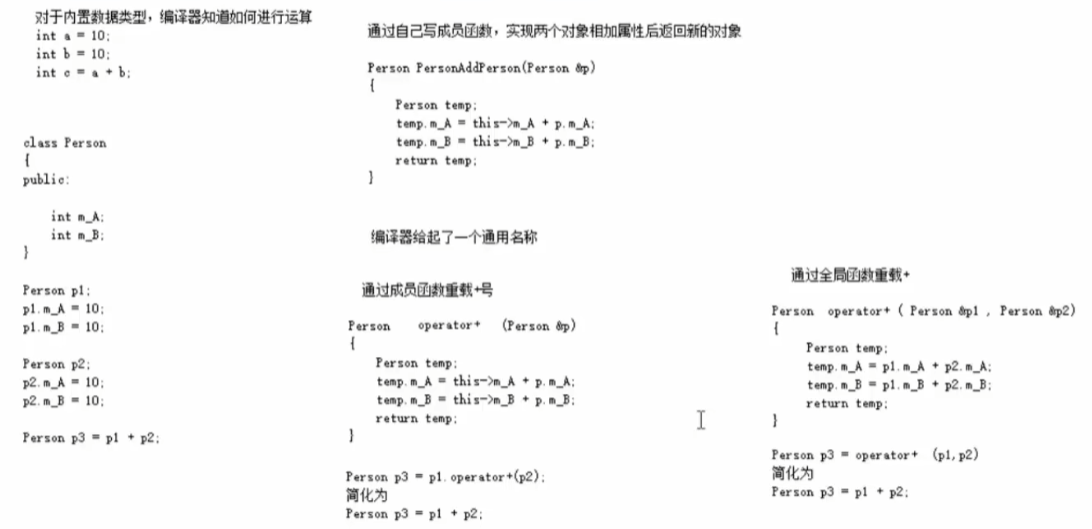

In [ ]:
#include <iostream>
using namespace std;

//加号运算符重载
class Person
{
public:

    //1、成员函数重载+号
    Person operator+(Person& p)
    {
        Person temp;
        temp.m_A = this->m_A + p.m_A;
        temp.m_B = this->m_B + p.m_B;
        return temp;
    }
    int m_A;
    int m_B;
};

/*
//全局函数重载+号
Person operator+(Person &p1, Person &p2)
{
    Person temp;
    temp.m_A = p1.m_A + p2.m_A;
    temp.m_B = p1.m_B + p2.m_B;
    return temp;
}
*/

//函数重载的版本
Person operator+(Person& p1, int num)
{
    Person temp;
    temp.m_A = p1.m_A + num;
    temp.m_B = p1.m_B + num;
    return temp; //不能返回临时变量的引用，可以返回临时变量的值
}

void test01()
{
    Person p1;
    p1.m_A = 10;
    p1.m_B = 10;
    Person p2;
    p2.m_A = 10;
    p2.m_B = 10;

    //成员函数重载本质调用 
    //Person p3 = p1.operator+(p2);
    
    //全局函数重载本质调用 
    //Person p3 = operator+(p1,p2);
    
    Person p3 = p1 + p2; //重载本质被简化后的形式

    //运算符重载，也可以发生函数重载

    Person p4 = p1 + 10; //Person + int

    cout << "p3.m_A：" << p3.m_A << endl;
    cout << "p3.m_B：" << p3.m_B << endl;

    cout << "p4.m_A：" << p4.m_A << endl;
    cout << "p4.m_B：" << p4.m_B << endl;

}


int main()
{
    test01();

    system("pause");

    return 0;

}

运行结果：  
 - p3.m_A：20  
 - p3.m_B：20  
 - p4.m_A：20  
 - p4.m_B：20  
 - 请按任意键继续. . .

# 3. 左移运算符重载

① 左移运算符重载：可以输出自定义数据类型。

② 重载左移运算符配合友元可以实现自定义数据类型。

In [ ]:
#include <iostream>
using namespace std;

//左移运算符
class Person
{

    friend ostream& operator<<(ostream& out, Person& p);	

public:
    Person(int a, int b)
    {
        m_A = a;
        m_B = b;
    }

    /*
    //利用成员函数重载 左移运算符  p.operator<<(cout) 简化版本 p << cout
    //成员函数不能利用重载<<运算符，因为无法实现cout在左侧
    //当不知道返回值是什么类型的时候，可以先写个void，以后再改
    void operator<<(Person& p)
    {
        
    }
    */
    
private:
    int m_A;
    int m_B;
};

//只能利用全局函数重载左移运算符
//如果返回类型为void，那么就无法无限追加，也没有办法在后面添加换行符
ostream & operator<<(ostream &cout, Person &p) //本质 operator << (cout , p) , 简化 cout << p
                                               //cout是别名，这里可以取out、kn...
                                               //cout为ostream输出流数据类型                                                    
//输出流不能拷贝，也就是说要传入输出流对象参数只能地址传递，不能值传递。流对象不能复制只能引用，记住就好了
{
    cout << "m_A= " << p.m_A << " m_B=" << p.m_B;
    return cout;
}

void test01()
{
    Person p(10,10);

    cout << p << " hello world" << endl;
}


int main()
{
    test01();

    system("pause");

    return 0;

}

运行结果：  
 - m_A= 10 m_B=10 hello world  
 - 请按任意键继续. . .

# 4. 递增运算符

① 递增运算符重载：通过重载递增运算符，实现自己的整型数据。

② 前置递增返回的是引用，后置递增返回的是值。

In [ ]:
#include <iostream>
using namespace std;

//重载递增运算符

class MyInteger
{
    friend ostream& operator<<(ostream& cout, MyInteger myint);

public:
    MyInteger()
    {
        m_Num = 0;
    }
    
    //重载前置++运算符,返回引用是为了一直对一个数据进行递增操作,而返回值并不是一直对一个数据进行递增操作                    
    MyInteger& operator++()
    {
        //先进行++运算
        m_Num++;

        //再将自身做一个返回
        return *this;  //把自身做一个返回
    }

    //重载后置++运算符 int代表占位参数，可以用于区分前置和后置递增
    //后置递增不能返回引用，因为temp是局部变量，如果返回temp，当程序运行完后变量就释放了，再调用temp就是非法操作了    
    //c++中的内置类型的后置++操作，产生的数据类型是右值，无法对于右值再进行++操作       
    MyInteger operator++(int)
    {
        //先记录当时结果
        MyInteger temp = *this;
        //后 递增
        m_Num++;
        //最后将记录结果做返回
        return temp;
    }
private:
    int m_Num;
};

//只能利用全局函数重载左移运算符
ostream & operator<<(ostream &cout, MyInteger myint) //本质 operator << (cout , p) , 简化 cout << p
                                                     //cout是别名，这里可以取out、kn...
                                                     //cout为ostream输出流数据类型                                               
{
    cout << myint.m_Num;

    return cout;
}

void test01()
{
    MyInteger myint;

    cout << ++(++myint) << endl;
    cout << myint << endl;
}

void test02()
{
    MyInteger myint;

    cout << myint++ << endl;
    cout << myint   << endl;

}

int main()
{
    test01();
    test02();

    /*
    int a = 0;
    cout << ++(++a) << endl; //运行结果为2
    cout << a << endl;       //运行结果为2，表示一直对一个数据进行递增
    */

    system("pause");

    return 0;

}

运行结果：  
 - 2  
 - 2  
 - 0  
 - 1  
 - 请按任意键继续. . .

# 5. 赋值运算符

① C++编译器至少给一个类添加4个函数：

1. 默认构造函数(无参，函数体为空)
2. 默认析构函数(无参，函数体为空)
3. 默认拷贝构造函数，对属性进行值拷贝
4. 赋值运算符operator=，对属性进行值拷贝
5. 如果类中有属性指向堆区，做赋值操作时也会出现浅拷贝问题。

浅拷贝
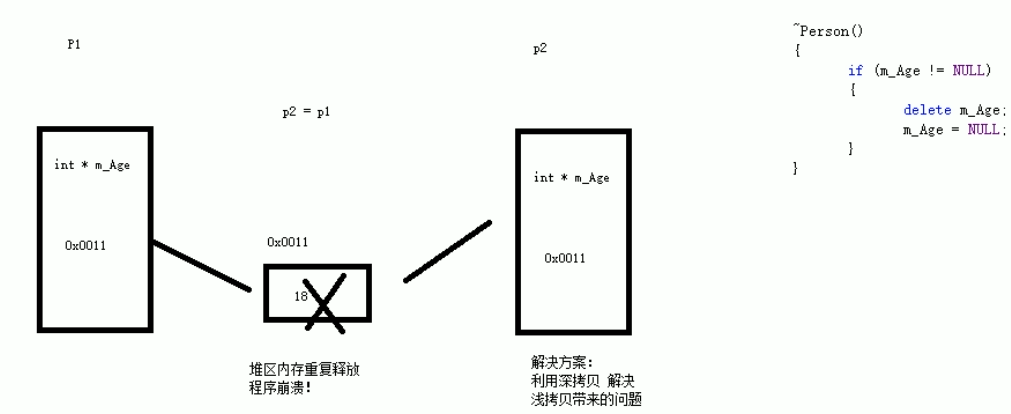
深拷贝
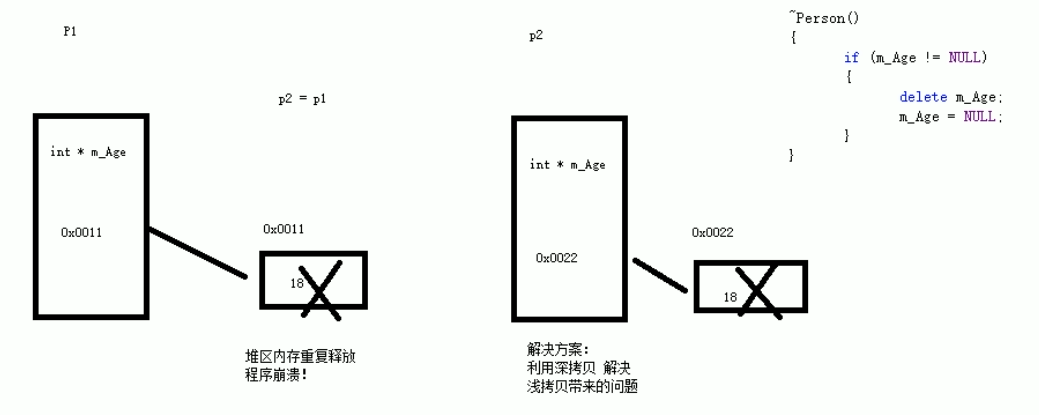

In [ ]:
#include <iostream>
using namespace std;

//重载赋值运算符

class Person
{
public:
    Person(int age)
    {
        m_Age = new int(age);
    }
    
    ~Person()
    {
        if (m_Age != NULL)
        {
            delete m_Age;
            m_Age = NULL;
        }
    }

    //重载 赋值运算符
    //如果返回的是值，而不是引用，是创建一个拷贝函数，返回的是一个副本，而不是自身
    Person& operator=(Person& p)
    {
        //编译器默认是提供浅拷贝
        //m_Age = p.m_Age;

        //浅拷贝带来的问题是，当创建数据在堆区时，析构代码导致内存重复释放，报错

        //应该先判断是否有属性在堆区，如果有先释放干净，然后再深拷贝
        if (m_Age != NULL)
        {
            delete m_Age;
            m_Age = NULL;
        }

        //深拷贝
        m_Age = new int(*p.m_Age);

        //返回对象本身
        return *this;
    }

    int *m_Age;
};

void test01()
{
    Person p1(18);

    Person p2(20);

    Person p3(23);

    p3 = p2 = p1; //赋值操作

    cout << "p1的年龄为：" << *p1.m_Age << endl;

    cout << "p2的年龄为：" << *p2.m_Age << endl;

    cout << "p3的年龄为：" << *p3.m_Age << endl;


}

int main()
{
    test01();

    /*
    
    int a = 10;
    int b = 20;
    int c = 30;
    
    c = b = a;

    cout << "a= " << a << endl;
    cout << "b= " << b << endl;
    cout << "c= " << c << endl;
    */

    system("pause");

    return 0;

}

运行结果：  
 - p1的年龄为：18  
 - p2的年龄为：18  
 - p3的年龄为：18  
 - 请按任意键继续. . .

# 6. 关系重载运算符

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//重载关系运算符

class Person
{
public:
    Person(string name, int age)
    {
        m_Name = name;
        m_Age = age;
    }

    //重载 == 号
    bool operator==(Person& p)
    {
        if (this->m_Name == p.m_Name && this->m_Age == p.m_Age)
        {
            return true;
        }
        return false;
    }

    bool operator!=(Person& p)
    {
        if (this->m_Name != p.m_Name || this->m_Age != p.m_Age)
        {
            return true;
        }
        return false;
    }

    string m_Name;
    int m_Age;
};

void test01()
{
    Person p1("Tom", 17);

    Person p2("Jerry", 18);

    if (p1 == p2)
    {
        cout << "p1和p2是相等的！" << endl;
    }
    else
    {
        cout << "p1和p2是不相等的！" << endl;

    }

    if (p1 != p2)
    {
        cout << "p1和p2是不相等的！" << endl;
    }
    else
    {
        cout << "p1和p2是相等的！" << endl;

    }


}

int main()
{
    test01();
    
    system("pause");

    return 0;

}

运行结果：  
 - p1和p2是不相等的！  
 - p1和p2是不相等的！  
 - 请按任意键继续. . .

# 7. 函数调用运算符重载

① 函数调用运算符()也可以重载。

② 由于重载后使用的方式非常像函数的调用，因此称为仿函数。

③ 仿函数没有固定写法，非常灵活。

In [ ]:
#include <iostream>
using namespace std;
#include<string>

//函数调用运算符重载

//打印输出类
class MyPrint
{
public:

    //重载函数调用运算符
    void operator()(string test)
    {
        cout << test << endl;
    }

};

//正常函数
void MyPrint02(string test)
{
    cout << test << endl;
}

void test01()
{
    MyPrint myPrint;

    myPrint("hello world");

}

//仿函数非常灵活，没有固定的写法
//加法类
class MyAdd
{
public:
    int operator()(int num1, int num2)
    {
        return num1 + num2;
    }
};

void test02()
{
    MyAdd myadd;
    int ret = myadd(100,100);
    cout << "ret = " << ret << endl;

    //匿名函数对象
    cout << MyAdd()(100, 100) << endl;

    // MyAdd()为创建一个匿名对象，匿名对象的特点为当前行执行完立即释放
}

int main()
{
    test01();

    MyPrint02("hello world"); //由于使用起来非常类似于函数调用，因此称为仿函数

    test02();

    system("pause");

    return 0;

}

运行结果：  
 - hello world  
 - hello world  
 - ret = 200  
 - 200  
 - 请按任意键继续. . .